# TurtleBot3 - LiDAR attacked: relying on a trusted peerScenario: `scenarios/turtlebot3_lidar_attacked_peer.yaml`

When the **own LiDAR is compromised** (`w9`) but a **trusted peer** (`w7`) exists, the scenario
proposes relying on the peer data to keep operating instead of stopping.

Facts introduced by the bridge node: `w4` (in motion), `w9` (own LiDAR compromised),
`w5`/`w6`/`w6b` (peer state) and `w7` (trusted peer).

*Scenario originally authored by Diego Pastrana (University of Leon); edited and provided with Jupyter notebooks in this repository.*


In [1]:
PATH = "../scenarios/turtlebot3_lidar_attacked_peer.yaml"

## Imports and utilities

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)

def run(facts, semantics="priority"):
    jim = load()
    args = jim.generate_arguments(facts)
    accepted, rejected = jim.compute_extension(args, semantics=semantics)
    decisions = sorted(a.hd for a in accepted if a.hd.startswith("d") or a.hd.startswith("p"))
    return decisions, jim, args, accepted, rejected

## Load the scenario

In [3]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Priorities:")
for k, v in sorted(jim.priorities.items()):
    print(f"  {k:<18} {v:>3}  - {jim.priority_desc.get(k, '')}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
Facts: ['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w6b', 'w7', 'w8', 'w9']
Number of norms: 18
Priorities:
  d_ignore_peer        8  - Ignoring untrusted peer has high priority for security.
  d_move              10  - Movement has the lowest priority among motion decisions. It is only selected when no safety or caution condition is active — reachable here via PR1 (i_no_own_data + w5 + w7) with no competing facts.
  d_prefer_safe        7  - Conservative default has high priority.
  d_slow_down         11  - Slowing down has the second-highest priority — caution takes precedence over free movement.
  d_stop              12  - Stopping always has the highest priority — safety-first principle. Any ambiguity or conflict must resolve towards the most conservative action.
  d_use_own_sensors    8  - Own sensor data is highly trusted when peer is compromised.


## Decision - Actual engine behaviourAlthough the YAML documents `w5+w7 -> d_move` and `w6+w7 -> d_slow_down`, the engine
**always returns `d_stop`**. The reason: the safety norm `SI2` (precautionary stop, priority 12)
defeats `PR1`/`PR2` (priority 10/11) through the priority ordering. Safety dominates.

In [4]:
cases = {
    "Peer clear": ['w4', 'w9', 'w5', 'w7'],
    "Peer with obstacle": ['w4', 'w9', 'w6', 'w7'],
    "Peer critical obstacle": ['w4', 'w9', 'w6b', 'w7']}

for name, facts in cases.items():
    decisions, _, _, _, _ = run(facts, "priority")
    print(f"{name:28s} {facts}  ->  {decisions}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000123 seconds
Peer clear                   ['w4', 'w9', 'w5', 'w7']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000116 seconds
Peer with obstacle           ['w4', 'w9', 'w6', 'w7']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000054 seconds
Peer critical obstacle       ['w4', 'w9', 'w6b', 'w7']  ->  ['d_prefer_safe', 'd_stop', 'd_stop']


## Comparison between semanticsFor the case `w4 w9 w5 w7` (peer clear):

In [5]:
facts = ["w4", "w9", "w5", "w7"]
for sem in ["naive", "stable", "grounded", "preferred", "priority", "jiminy"]:
    decisions, _, _, _, _ = run(facts, sem)
    print(f"{sem:<12}{decisions}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'naive'
naive       ['d_prefer_safe']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'stable'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000012 seconds
stable      []
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'grounded'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000054 seconds
grounded    ['d_prefer_safe', 'p_continue']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'preferred'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000356 seconds
preferred   ['d_prefer_safe', 'p_continue']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000103 seconds
priority    ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-p

## Narrative explanation

In [6]:
facts = ['w4', 'w9', 'w5', 'w7']
decisions, jim, args, accepted, rejected = run(facts, "priority")
print(jim.explain(accepted, rejected, facts, semantics="priority"))

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000102 seconds
CONTEXT ANALYSIS
------------------------------------------------------------
 - w4
 - w5
 - w7
 - w9

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w9',) ⇒ i_no_own_data (Institutional fact, stakeholder=Safety)
 - ('w5', 'w7') ⇒ i_peer_clear (Institutional fact, stakeholder=MultiRobot)
 - ('i_no_own_data', 'w4') ⇒ d_stop (Obligation, stakeholder=Safety)
 - ('i_no_own_data', 'w5', 'w7') ⇒ d_move (Obligation, stakeholder=MultiRobot)
 - ('i_peer_clear',) ⇒ p_continue (Permission, stakeholder=MultiRobot)
 - () ⇒ d_prefer_safe (Obligation, stakeholder=Manufacturer)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_stop conflicts with: d_slow_down, d_move
 - d_move conflicts with: d_slow_down, d_stop
 - p_continue conflicts with: d_stop
 - d_prefer_

## Argumentation attack diagramActivating the full context lets all contrary decisions coexist, so everyattack (chi, red) and defeat (>, dashed blue) relation of the argumentationframework is drawn. Nodes with a double border are accepted by the `priority` semantics.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000161 seconds
[Visualizer] Rendering graph → tb_peer_af.png


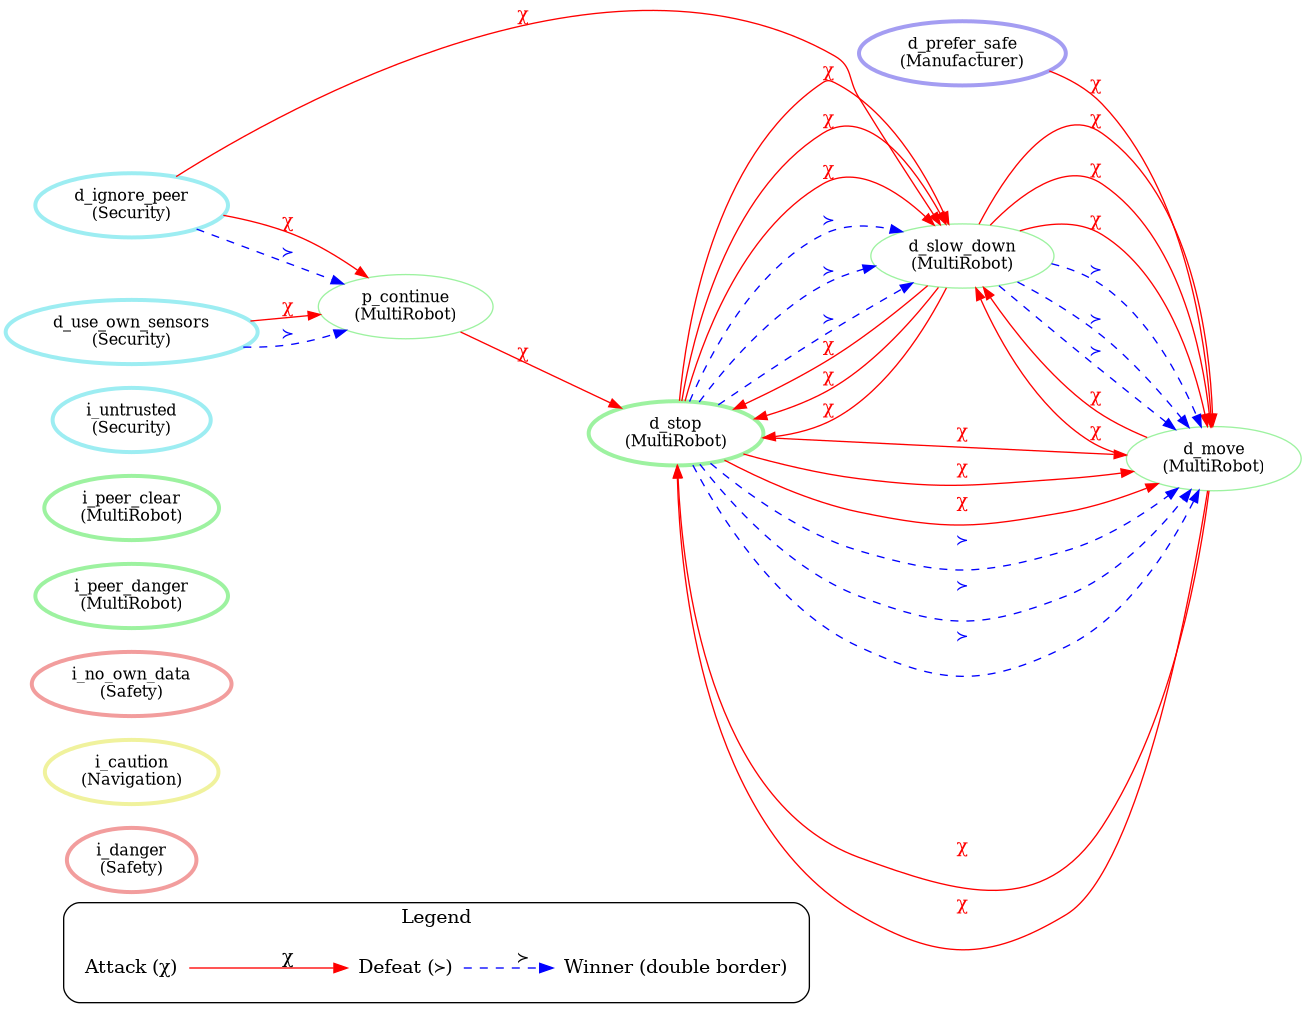


=== Attack relations present ===
  d_stop  <->  d_slow_down
  d_stop  <->  d_move
  d_slow_down  <->  d_move
  d_slow_down  <->  d_stop
  d_move  <->  d_slow_down
  d_move  <->  d_stop
  d_ignore_peer  <->  d_slow_down
  d_ignore_peer  <->  p_continue
  d_use_own_sensors  <->  p_continue
  p_continue  <->  d_stop
  d_prefer_safe  <->  d_move


In [7]:
from IPython.display import Image, display

jim = load()
all_facts = list(load_scenario(PATH)[0])
args = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args, semantics="priority")

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in accepted},
                priorities=jim.priorities, contrariness=jim.contrariness)
name = "tb_peer_af"
av.render(name)
display(Image(filename=f"{name}.png"))

print("\n=== Attack relations present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")

## Graphviz Advanced Exports - Reasoning graphApproach taken from the `jiminy_example` notebook (`export_reasoning_graph`, the 2nd figure).It shows the reasoning dependency chain: facts (blue) -> institutional facts (green) ->decisions (orange = accepted, gray = rejected), with the norm descriptions as labels.A color legend is embedded in the graph.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000261 seconds


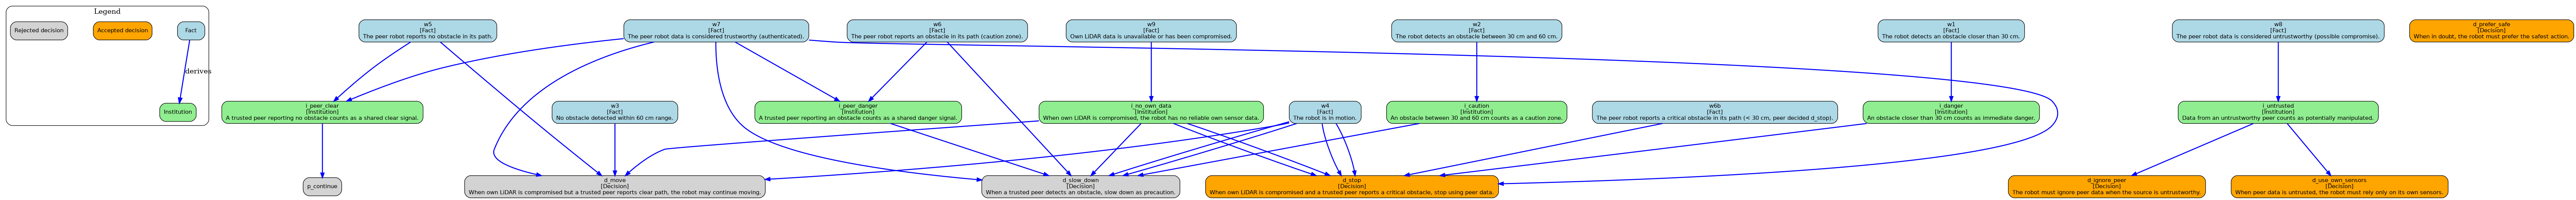

In [8]:
# --- Graphviz Advanced Exports: reasoning graph (2nd figure of jiminy_example) ---
from graphviz import Digraph
from IPython.display import Image, display

# Build a label for each atom, attaching its textual description
def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    # Color legend so the diagram is easier to read
    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []

    # Collect nodes and derivation edges from every argument
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)

        body = getattr(a.origin_norm, "body", [])
        for b in body:
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    # Color nodes by type (facts / institutions / decisions)
    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        color = "orange" if d in winners else "lightgray"
        g.node(d, label=build_label(d), fillcolor=color)

    # Draw the derivation edges (body -> head)
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

# Rebuild the framework over the full context
jim = load()
all_facts = list(load_scenario(PATH)[0])
args_final = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args_final, semantics="priority")

display(Image(filename=export_reasoning_graph("tb_peer_reasoning")))